In [ ]:
!pip -q install timm==1.* scikit-learn==1.* pandas==2.* matplotlib==3.* tqdm==4.*

In [ ]:
import os, gc, random, json, time
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
from timm.utils import ModelEmaV2
from timm.data import resolve_data_config, create_transform

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

In [ ]:
SEED = 1729
def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
use_amp = (device == "cuda")

In [ ]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

CUB_ROOT = Path("/content/drive/MyDrive/CUB_200_2011")
ART_DIR  = CUB_ROOT / "_artifacts"

MODELS_DIR = Path("/content/drive/MyDrive/deep_learning_models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [ ]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
gc.collect()
torch.cuda.empty_cache()

print("device:", device, "| amp:", use_amp)
print("ART_DIR:", ART_DIR)
print("MODELS_DIR:", MODELS_DIR)
!nvidia-smi

device: cuda | amp: True
ART_DIR: /content/drive/MyDrive/CUB_200_2011/_artifacts
MODELS_DIR: /content/drive/MyDrive/deep_learning_models
Wed Feb 18 22:05:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             40W /  400W |       6MiB /  40960MiB |      0%      Default |
|  

In [ ]:
df = pd.read_csv(ART_DIR / "metadata.csv")
train_ids = np.load(ART_DIR / "train_ids.npy")
val_ids   = np.load(ART_DIR / "val_ids.npy")
test_ids  = np.load(ART_DIR / "test_ids.npy")

train_df = df[df["image_id"].isin(train_ids)].copy()
val_df   = df[df["image_id"].isin(val_ids)].copy()
test_df  = df[df["image_id"].isin(test_ids)].copy()

NUM_CLASSES = int(df["class_id"].nunique())
assert NUM_CLASSES == 200, f"Expected 200 classes, got {NUM_CLASSES}"

print("Splits:", len(train_df), len(val_df), len(test_df))
print("Train classes:", train_df["class_id"].nunique(), "Val classes:", val_df["class_id"].nunique())
print("class_id min/max:", df["class_id"].min(), df["class_id"].max())

Splits: 5394 600 5794
Train classes: 200 Val classes: 200
class_id min/max: 1 200


In [ ]:
class CUBDataset(Dataset):
    """
    crop_mode:
      - "full": use full image
      - "bbox": crop using provided bounding box (+ padding)
    """
    def __init__(self, frame: pd.DataFrame, tfm, crop_mode: str = "full", pad_frac: float = 0.08):
        self.frame = frame.reset_index(drop=True)
        self.tfm = tfm
        self.crop_mode = crop_mode
        self.pad_frac = float(pad_frac)
        if crop_mode not in {"full", "bbox"}:
            raise ValueError("crop_mode must be 'full' or 'bbox'")

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx: int):
        r = self.frame.iloc[idx]
        img = Image.open(r["abs_path"]).convert("RGB")

        if self.crop_mode == "bbox":
            x, y, w, h = float(r["x"]), float(r["y"]), float(r["w"]), float(r["h"])
            pad_w = self.pad_frac * w
            pad_h = self.pad_frac * h

            left   = max(0, int(x - pad_w))
            top    = max(0, int(y - pad_h))
            right  = min(img.width,  int(x + w + pad_w))
            bottom = min(img.height, int(y + h + pad_h))
            img = img.crop((left, top, right, bottom))

        img = self.tfm(img)

        # CUB labels are 1..200 -> shift to 0..199
        label = int(r["class_id"]) - 1
        image_id = int(r["image_id"])
        return img, label, image_id

In [ ]:
# EfficientNet-B4 canonical resolution is 380
MODEL_NAME = "tf_efficientnet_b4"
IMG_SIZE   = 380

BATCH_SIZE = 64
NUM_WORKERS = 8
PIN_MEMORY = True
PERSISTENT_WORKERS = False  # avoid pin-memory thread issues in Colab

In [ ]:
train_tfm = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(0.15, 0.15, 0.15, 0.05),
    T.ToTensor(),
    T.Normalize((0.485,0.456,0.406), (0.229,0.224,0.225)),
])

eval_tfm = T.Compose([
    T.Resize(int(IMG_SIZE / 0.875), interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize((0.485,0.456,0.406), (0.229,0.224,0.225)),
])

In [ ]:
def make_loaders(crop_mode: str):
    train_ds = CUBDataset(train_df, train_tfm, crop_mode=crop_mode, pad_frac=0.08)
    val_ds   = CUBDataset(val_df,   eval_tfm,  crop_mode=crop_mode, pad_frac=0.08)
    test_ds  = CUBDataset(test_df,  eval_tfm,  crop_mode=crop_mode, pad_frac=0.08)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS
    )
    return train_loader, val_loader, test_loader

In [ ]:
train_loader_full, val_loader_full, _ = make_loaders("full")
xb, yb, _ = next(iter(train_loader_full))
print("Batch x:", xb.shape, xb.dtype)
print("Batch y:", yb.shape, yb.dtype, "min/max:", int(yb.min()), int(yb.max()))

m = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES).to(device)
m.eval()
with torch.no_grad():
    x2 = xb[:2].to(device)
    with torch.amp.autocast("cuda", enabled=use_amp):
        out = m(x2)
print("Logits:", out.shape, out.dtype)
assert out.shape == (2, NUM_CLASSES)
del m
torch.cuda.empty_cache()

Batch x: torch.Size([64, 3, 380, 380]) torch.float32
Batch y: torch.Size([64]) torch.int64 min/max: 1 192


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Logits: torch.Size([2, 200]) torch.float16


In [ ]:
@torch.no_grad()
def predict_all(model: nn.Module, loader: DataLoader):
    model.eval()
    y_true, y_pred, img_ids = [], [], []
    for x, y, iid in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(x)
        p = torch.argmax(logits, dim=1)
        y_true.append(y.cpu().numpy())
        y_pred.append(p.cpu().numpy())
        img_ids.append(iid.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(img_ids)

In [ ]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int):
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec_macro  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro   = f1_score(y_true, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))
    return {
        "accuracy": float(acc),
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "confusion_matrix": cm,
    }

In [ ]:
def print_metrics(title: str, m: dict):
    print(f"\n=== {title} ===")
    print(f"Accuracy         : {m['accuracy']:.4f}")
    print(f"Precision (macro): {m['precision_macro']:.4f}")
    print(f"Recall (macro)   : {m['recall_macro']:.4f}")
    print(f"F1 (macro)       : {m['f1_macro']:.4f}")
    print("Confusion matrix :", m["confusion_matrix"].shape)

In [ ]:
def save_predictions_csv(out_path: Path, img_ids, y_true, y_pred):
    pd.DataFrame({
        "image_id": img_ids.astype(int),
        "true_label": y_true.astype(int),
        "pred_label": y_pred.astype(int),
    }).to_csv(out_path, index=False)
    print("Wrote predictions:", out_path)

In [ ]:
EPOCHS_STAGE1 = 1
EPOCHS_STAGE2 = 8
PATIENCE = 2

LR_STAGE1 = 2e-3
LR_STAGE2 = 5e-4
WEIGHT_DECAY = 0.02

LABEL_SMOOTH = 0.1
GRAD_CLIP_NORM = 1.0

In [ ]:
def build_model(pretrained: bool):
    return timm.create_model(MODEL_NAME, pretrained=pretrained, num_classes=NUM_CLASSES)

In [ ]:
def freeze_backbone(model: nn.Module):
    # Freeze all params
    for p in model.parameters():
        p.requires_grad = False
    # Unfreeze classifier head
    head = model.get_classifier()
    for p in head.parameters():
        p.requires_grad = True

In [ ]:
def unfreeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True

In [ ]:
def train_two_stage(crop_mode: str, ckpt_path: Path, run_name: str):
    train_loader, val_loader, _ = make_loaders(crop_mode)

    model = build_model(pretrained=True).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_val = 0.0
    best_epoch = -1
    bad_epochs = 0

    # ---------------- Stage 1: train head only ----------------
    freeze_backbone(model)

    opt = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_STAGE1,
    weight_decay=WEIGHT_DECAY
    )

    for epoch in range(1, EPOCHS_STAGE1 + 1):
        model.train()
        loop = tqdm(train_loader, desc=f"{run_name} | S1 {epoch}/{EPOCHS_STAGE1}")
        for x, y, _ in loop:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(opt)
            scaler.update()
            loop.set_postfix(loss=float(loss.detach().cpu()))

        yv_true, yv_pred, _ = predict_all(model, val_loader)
        m = compute_metrics(yv_true, yv_pred, NUM_CLASSES)
        print_metrics(f"{run_name} | VAL after S1", m)

    # ---------------- Stage 2: fine-tune all ----------------
    unfreeze_all(model)

    opt = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_STAGE1,
    weight_decay=WEIGHT_DECAY
    )
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_STAGE2)

    for epoch in range(1, EPOCHS_STAGE2 + 1):
        model.train()
        loop = tqdm(train_loader, desc=f"{run_name} | S2 {epoch}/{EPOCHS_STAGE2}")
        for x, y, _ in loop:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(opt)
            scaler.update()
            loop.set_postfix(loss=float(loss.detach().cpu()), lr=float(opt.param_groups[0]["lr"]))

        sched.step()

        yv_true, yv_pred, _ = predict_all(model, val_loader)
        m = compute_metrics(yv_true, yv_pred, NUM_CLASSES)
        print_metrics(f"{run_name} | VAL (S2)", m)

        if m["accuracy"] > best_val:
            best_val = m["accuracy"]
            best_epoch = epoch
            bad_epochs = 0
            torch.save({
                "model": model.state_dict(),
                "seed": SEED,
                "val_acc": best_val,
                "model_name": MODEL_NAME,
                "img_size": IMG_SIZE,
                "crop_mode": crop_mode,
                "batch_size": BATCH_SIZE,
                "lr_stage1": LR_STAGE1,
                "lr_stage2": LR_STAGE2,
                "optimizer": "SGD+Nesterov",
                "momentum": MOMENTUM,
                "weight_decay": WEIGHT_DECAY,
            }, ckpt_path)
            print("Saved best:", ckpt_path)
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"Early stopping (no val improvement for {PATIENCE} epochs).")
                break

    print(f"{run_name} best val: {best_val:.4f} at stage2 epoch {best_epoch}")

    del model
    gc.collect()
    torch.cuda.empty_cache()
    return ckpt_path

In [ ]:
CKPT_FULL = MODELS_DIR / f"A_{MODEL_NAME}_{IMG_SIZE}_full_best.pt"

print("CKPT_FULL:", CKPT_FULL)

ckpt_full = train_two_stage("full", CKPT_FULL, run_name="A_EFFB4_FULL")

CKPT_FULL: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_full_best.pt


A_EFFB4_FULL | S1 1/1: 100%|██████████| 85/85 [00:27<00:00,  3.04it/s, loss=3.17]



=== A_EFFB4_FULL | VAL after S1 ===
Accuracy         : 0.4050
Precision (macro): 0.3994
Recall (macro)   : 0.4050
F1 (macro)       : 0.3635
Confusion matrix : (200, 200)


A_EFFB4_FULL | S2 1/8: 100%|██████████| 85/85 [00:29<00:00,  2.91it/s, loss=2.79, lr=0.002]



=== A_EFFB4_FULL | VAL (S2) ===
Accuracy         : 0.5083
Precision (macro): 0.5228
Recall (macro)   : 0.5083
F1 (macro)       : 0.4711
Confusion matrix : (200, 200)
Saved best: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_full_best.pt


...


=== A_EFFB4_FULL | VAL (S2) ===
Accuracy         : 0.8350
Precision (macro): 0.8544
Recall (macro)   : 0.8350
F1 (macro)       : 0.8265
Confusion matrix : (200, 200)
Saved best: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_full_best.pt


A_EFFB4_FULL | S2 7/8: 100%|██████████| 85/85 [00:30<00:00,  2.78it/s, loss=1, lr=0.000293]



=== A_EFFB4_FULL | VAL (S2) ===
Accuracy         : 0.8533
Precision (macro): 0.8746
Recall (macro)   : 0.8533
F1 (macro)       : 0.8461
Confusion matrix : (200, 200)
Saved best: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_full_best.pt


A_EFFB4_FULL | S2 8/8: 100%|██████████| 85/85 [00:30<00:00,  2.79it/s, loss=0.945, lr=7.61e-5]



=== A_EFFB4_FULL | VAL (S2) ===
Accuracy         : 0.8550
Precision (macro): 0.8788
Recall (macro)   : 0.8550
F1 (macro)       : 0.8494
Confusion matrix : (200, 200)
Saved best: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_full_best.pt
A_EFFB4_FULL best val: 0.8550 at stage2 epoch 8


In [ ]:
CKPT_BBOX = MODELS_DIR / f"A_{MODEL_NAME}_{IMG_SIZE}_bbox_best.pt"

print("CKPT_BBOX:", CKPT_BBOX)

ckpt_bbox = train_two_stage("bbox", CKPT_BBOX, run_name="A_EFFB4_BBOX")

CKPT_BBOX: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_bbox_best.pt


A_EFFB4_BBOX | S1 1/1: 100%|██████████| 85/85 [00:28<00:00,  3.00it/s, loss=3.25]



=== A_EFFB4_BBOX | VAL after S1 ===
Accuracy         : 0.3950
Precision (macro): 0.4104
Recall (macro)   : 0.3950
F1 (macro)       : 0.3642
Confusion matrix : (200, 200)


A_EFFB4_BBOX | S2 1/8: 100%|██████████| 85/85 [00:28<00:00,  2.97it/s, loss=2.19, lr=0.002]



=== A_EFFB4_BBOX | VAL (S2) ===
Accuracy         : 0.5517
Precision (macro): 0.5994
Recall (macro)   : 0.5517
F1 (macro)       : 0.5249
Confusion matrix : (200, 200)
Saved best: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_bbox_best.pt


...


=== A_EFFB4_BBOX | VAL (S2) ===
Accuracy         : 0.7983
Precision (macro): 0.8249
Recall (macro)   : 0.7983
F1 (macro)       : 0.7887
Confusion matrix : (200, 200)
Saved best: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_bbox_best.pt


A_EFFB4_BBOX | S2 7/8: 100%|██████████| 85/85 [00:29<00:00,  2.87it/s, loss=0.973, lr=0.000293]



=== A_EFFB4_BBOX | VAL (S2) ===
Accuracy         : 0.8083
Precision (macro): 0.8275
Recall (macro)   : 0.8083
F1 (macro)       : 0.7972
Confusion matrix : (200, 200)
Saved best: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_bbox_best.pt


A_EFFB4_BBOX | S2 8/8: 100%|██████████| 85/85 [00:29<00:00,  2.84it/s, loss=1.04, lr=7.61e-5]



=== A_EFFB4_BBOX | VAL (S2) ===
Accuracy         : 0.8000
Precision (macro): 0.8167
Recall (macro)   : 0.8000
F1 (macro)       : 0.7863
Confusion matrix : (200, 200)
A_EFFB4_BBOX best val: 0.8083 at stage2 epoch 7


In [ ]:
def load_model_from_ckpt(ckpt_path: Path):
    ckpt = torch.load(ckpt_path, map_location=device)
    model = build_model(pretrained=False).to(device)
    model.load_state_dict(ckpt["model"], strict=True)
    return model, ckpt

In [ ]:
# FULL val
train_loader, val_loader_full, _ = make_loaders("full")
model_full, ckpt_meta_full = load_model_from_ckpt(ckpt_full)
yv_true, yv_pred, yv_ids = predict_all(model_full, val_loader_full)
m_full = compute_metrics(yv_true, yv_pred, NUM_CLASSES)
print_metrics("VAL | FULL", m_full)
save_predictions_csv(MODELS_DIR / f"pred_A_{MODEL_NAME}_{IMG_SIZE}_full_val.csv", yv_ids, yv_true, yv_pred)
del model_full
torch.cuda.empty_cache()


=== VAL | FULL ===
Accuracy         : 0.8550
Precision (macro): 0.8788
Recall (macro)   : 0.8550
F1 (macro)       : 0.8494
Confusion matrix : (200, 200)
Wrote predictions: /content/drive/MyDrive/deep_learning_models/pred_A_tf_efficientnet_b4_380_full_val.csv


In [ ]:
# BBOX val
_, val_loader_bbox, _ = make_loaders("bbox")
model_bbox, ckpt_meta_bbox = load_model_from_ckpt(ckpt_bbox)
yv_true, yv_pred, yv_ids = predict_all(model_bbox, val_loader_bbox)
m_bbox = compute_metrics(yv_true, yv_pred, NUM_CLASSES)
print_metrics("VAL | BBOX", m_bbox)
save_predictions_csv(MODELS_DIR / f"pred_A_{MODEL_NAME}_{IMG_SIZE}_bbox_val.csv", yv_ids, yv_true, yv_pred)
del model_bbox
torch.cuda.empty_cache()


=== VAL | BBOX ===
Accuracy         : 0.8083
Precision (macro): 0.8275
Recall (macro)   : 0.8083
F1 (macro)       : 0.7972
Confusion matrix : (200, 200)
Wrote predictions: /content/drive/MyDrive/deep_learning_models/pred_A_tf_efficientnet_b4_380_bbox_val.csv


In [ ]:
print("\nVAL acc FULL:", m_full["accuracy"])
print("VAL acc BBOX:", m_bbox["accuracy"])

winner = "full" if m_full["accuracy"] >= m_bbox["accuracy"] else "bbox"
print("Winner on VAL:", winner)


VAL acc FULL: 0.855
VAL acc BBOX: 0.8083333333333333
Winner on VAL: full


In [ ]:
# FULL only high setting
CROP_MODE = "full"

# epochs
EPOCHS_STAGE1 = 1
EPOCHS_STAGE2 = 18
PATIENCE = 4

# optimizer + schedule
LR_STAGE1 = 2e-3
LR_STAGE2 = 6e-4
WEIGHT_DECAY = 0.02
WARMUP_EPOCHS = 2  # within stage2

LABEL_SMOOTH = 0.1
GRAD_CLIP_NORM = 1.0

# EMA (big gain often)
EMA_DECAY = 0.9998

# batch/workers (keep stable)
BATCH_SIZE = 64
NUM_WORKERS = 4
PIN_MEMORY = True
PERSISTENT_WORKERS = False

RUN_NAME = f"A_EFFB4_FULL_HS"
CKPT_FULL_HS = MODELS_DIR / f"A_tf_efficientnet_b4_380_full_HS_best.pt"

print("RUN_NAME:", RUN_NAME)
print("CKPT:", CKPT_FULL_HS)

RUN_NAME: A_EFFB4_FULL_HS
CKPT: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_full_HS_best.pt


In [ ]:
tmp_model = timm.create_model("tf_efficientnet_b4", pretrained=True, num_classes=NUM_CLASSES).to(device)
data_cfg = resolve_data_config({}, model=tmp_model)
del tmp_model
torch.cuda.empty_cache()

train_tfm = create_transform(**data_cfg, is_training=True)
eval_tfm  = create_transform(**data_cfg, is_training=False)

# mild extra regularization
train_tfm.transforms.append(T.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3)))
print("Updated transforms.")

Updated transforms.


In [ ]:
# FULL only
CROP_MODE = "full"

EPOCHS_STAGE1 = 1
EPOCHS_STAGE2 = 18
PATIENCE = 4

LR_STAGE1 = 2e-3
LR_STAGE2 = 6e-4
WEIGHT_DECAY = 0.02
WARMUP_EPOCHS = 2

LABEL_SMOOTH = 0.1
GRAD_CLIP_NORM = 1.0

EMA_DECAY = 0.9998

RUN_NAME = "A_EFFB4_FULL_HS"
CKPT_FULL_HS = MODELS_DIR / "A_tf_efficientnet_b4_380_full_HS_best.pt"

print("High-setting config loaded:", RUN_NAME)

High-setting config loaded: A_EFFB4_FULL_HS


In [ ]:
def set_lr(optimizer, lr: float):
    for pg in optimizer.param_groups:
        pg["lr"] = float(lr)

In [ ]:
def train_modelA_full_high_setting():
    gc.collect()
    torch.cuda.empty_cache()

    train_loader, val_loader, _ = make_loaders("full")

    model = timm.create_model("tf_efficientnet_b4", pretrained=True, num_classes=NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    # ---- Stage 1: head warm-up ----
    for p in model.parameters():
        p.requires_grad = False
    for p in model.get_classifier().parameters():
        p.requires_grad = True

    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_STAGE1,
        weight_decay=WEIGHT_DECAY
    )

    model.train()
    loop = tqdm(train_loader, desc=f"{RUN_NAME} | S1 1/{EPOCHS_STAGE1}")
    for x, y, _ in loop:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(opt)
        scaler.update()
        loop.set_postfix(loss=float(loss.detach().cpu()))

    # ---- Stage 2: unfreeze all + EMA + warmup + cosine ----
    for p in model.parameters():
        p.requires_grad = True

    opt = torch.optim.AdamW(model.parameters(), lr=LR_STAGE2, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, EPOCHS_STAGE2 - WARMUP_EPOCHS))

    ema = ModelEmaV2(model, decay=EMA_DECAY, device=None)

    best_val = 0.0
    bad = 0

    for epoch in range(1, EPOCHS_STAGE2 + 1):
        model.train()

        if epoch <= WARMUP_EPOCHS:
            set_lr(opt, LR_STAGE2 * (epoch / WARMUP_EPOCHS))

        loop = tqdm(train_loader, desc=f"{RUN_NAME} | S2 {epoch}/{EPOCHS_STAGE2}")
        for x, y, _ in loop:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(opt)
            scaler.update()

            ema.update(model)
            loop.set_postfix(loss=float(loss.detach().cpu()), lr=float(opt.param_groups[0]["lr"]))

        if epoch > WARMUP_EPOCHS:
            sched.step()

        yv_true, yv_pred, _ = predict_all(ema.module, val_loader)
        m = compute_metrics(yv_true, yv_pred, NUM_CLASSES)
        print_metrics(f"{RUN_NAME} | VAL EMA", m)

        if m["accuracy"] > best_val:
            best_val = m["accuracy"]
            bad = 0
            torch.save(
                {
                    "model": ema.module.state_dict(),
                    "seed": SEED,
                    "val_acc": best_val,
                    "model_name": "tf_efficientnet_b4",
                    "img_size": 380,
                    "crop_mode": "full",
                    "batch_size": BATCH_SIZE,
                    "lr_stage2": LR_STAGE2,
                    "weight_decay": WEIGHT_DECAY,
                    "ema_decay": EMA_DECAY,
                    "epochs_stage2": EPOCHS_STAGE2,
                    "warmup_epochs": WARMUP_EPOCHS,
                },
                CKPT_FULL_HS
            )
            print("Saved best:", CKPT_FULL_HS)
        else:
            bad += 1
            if bad >= PATIENCE:
                print(f"Early stopping. Best val={best_val:.4f}")
                break

    del model
    gc.collect()
    torch.cuda.empty_cache()
    return CKPT_FULL_HS, best_val

In [ ]:
ckpt_hs, best_val_hs = train_modelA_full_high_setting()
print("Best VAL (HS):", best_val_hs, "CKPT:", ckpt_hs)

A_EFFB4_FULL_HS | S1 1/1: 100%|██████████| 85/85 [00:26<00:00,  3.15it/s, loss=3.94]
A_EFFB4_FULL_HS | S2 1/18: 100%|██████████| 85/85 [00:29<00:00,  2.89it/s, loss=2.07, lr=0.0003]



=== A_EFFB4_FULL_HS | VAL EMA ===
Accuracy         : 0.5000
Precision (macro): 0.4848
Recall (macro)   : 0.5000
F1 (macro)       : 0.4532
Confusion matrix : (200, 200)
Saved best: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_full_HS_best.pt


A_EFFB4_FULL_HS | S2 2/18: 100%|██████████| 85/85 [00:30<00:00,  2.81it/s, loss=1.6, lr=0.0006]



=== A_EFFB4_FULL_HS | VAL EMA ===
Accuracy         : 0.5083
Precision (macro): 0.4967
Recall (macro)   : 0.5083
F1 (macro)       : 0.4623
Confusion matrix : (200, 200)
Saved best: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_full_HS_best.pt


A_EFFB4_FULL_HS | S2 3/18: 100%|██████████| 85/85 [00:30<00:00,  2.82it/s, loss=2.14, lr=0.0006]


...


=== A_EFFB4_FULL_HS | VAL EMA ===
Accuracy         : 0.7167
Precision (macro): 0.7351
Recall (macro)   : 0.7167
F1 (macro)       : 0.6908
Confusion matrix : (200, 200)
Saved best: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_full_HS_best.pt


A_EFFB4_FULL_HS | S2 17/18: 100%|██████████| 85/85 [00:29<00:00,  2.84it/s, loss=1.06, lr=2.28e-5]



=== A_EFFB4_FULL_HS | VAL EMA ===
Accuracy         : 0.7267
Precision (macro): 0.7438
Recall (macro)   : 0.7267
F1 (macro)       : 0.7008
Confusion matrix : (200, 200)
Saved best: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_full_HS_best.pt


A_EFFB4_FULL_HS | S2 18/18: 100%|██████████| 85/85 [00:30<00:00,  2.83it/s, loss=1.15, lr=5.76e-6]



=== A_EFFB4_FULL_HS | VAL EMA ===
Accuracy         : 0.7433
Precision (macro): 0.7569
Recall (macro)   : 0.7433
F1 (macro)       : 0.7167
Confusion matrix : (200, 200)
Saved best: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_full_HS_best.pt
Best VAL (HS): 0.7433333333333333 CKPT: /content/drive/MyDrive/deep_learning_models/A_tf_efficientnet_b4_380_full_HS_best.pt


In [ ]:
MODEL_NAME = "tf_efficientnet_b4"
CROP_MODE  = "full"

PHASE1_IMG = 320
PHASE1_EPOCHS = 12

PHASE2_IMG = 380
PHASE2_EPOCHS = 100

BATCH_SIZE = 64
NUM_WORKERS = 4
PIN_MEMORY = True
PERSISTENT_WORKERS = False

WEIGHT_DECAY = 0.02
LABEL_SMOOTH = 0.1
GRAD_CLIP_NORM = 1.0

LR1 = 8e-4          # phase 1
LR2 = 2.5e-4        # phase 2 (lower for long fine-tune)

WARMUP_EPOCHS = 6
PATIENCE = 6

USE_EMA = True
EMA_DECAY = 0.9998

CKPT_LONG = MODELS_DIR / "A_effb4_full_LONG_best_2.pt"
print("CKPT_LONG:", CKPT_LONG)

CKPT_LONG: /content/drive/MyDrive/deep_learning_models/A_effb4_full_LONG_best_2.pt


In [ ]:
def make_loaders_for(img_size: int, crop_mode: str):
    # Build transforms from timm model config
    tmp = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES).to(device)
    cfg = resolve_data_config({"input_size": (3, img_size, img_size)}, model=tmp)
    del tmp
    torch.cuda.empty_cache()

    train_tfm = create_transform(**cfg, is_training=True)
    eval_tfm  = create_transform(**cfg, is_training=False)

    train_ds = CUBDataset(train_df, train_tfm, crop_mode=crop_mode, pad_frac=0.08)
    val_ds   = CUBDataset(val_df,   eval_tfm,  crop_mode=crop_mode, pad_frac=0.08)
    test_ds  = CUBDataset(test_df,  eval_tfm,  crop_mode=crop_mode, pad_frac=0.08)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS
    )
    return train_loader, val_loader, test_loader, eval_tfm

In [ ]:
def set_lr(opt, lr: float):
    for pg in opt.param_groups:
        pg["lr"] = float(lr)

In [ ]:
def run_long_full_training():
    gc.collect()
    torch.cuda.empty_cache()

    model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    ema = ModelEmaV2(model, decay=EMA_DECAY, device=None) if USE_EMA else None

    best_val = 0.0
    bad = 0

    def train_phase(img_size: int, epochs: int, lr: float, tag: str):
        nonlocal best_val, bad

        train_loader, val_loader, _, _ = make_loaders_for(img_size, CROP_MODE)

        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, epochs - WARMUP_EPOCHS))

        for epoch in range(1, epochs + 1):
            model.train()

            if epoch <= WARMUP_EPOCHS:
                set_lr(opt, lr * (epoch / WARMUP_EPOCHS))

            loop = tqdm(train_loader, desc=f"LONG | {tag} | {epoch}/{epochs}")
            for x, y, _ in loop:
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)

                opt.zero_grad(set_to_none=True)
                with torch.amp.autocast("cuda", enabled=use_amp):
                    logits = model(x)
                    loss = criterion(logits, y)

                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                scaler.step(opt)
                scaler.update()

                if ema is not None:
                    ema.update(model)

                loop.set_postfix(loss=float(loss.detach().cpu()), lr=float(opt.param_groups[0]["lr"]))

            if epoch > WARMUP_EPOCHS:
                sched.step()

            eval_model = ema.module if ema is not None else model
            yv_true, yv_pred, _ = predict_all(eval_model, val_loader)
            m = compute_metrics(yv_true, yv_pred, NUM_CLASSES)
            print_metrics(f"VAL | {tag} | EMA={ema is not None}", m)

            if m["accuracy"] > best_val:
                best_val = m["accuracy"]
                bad = 0
                torch.save(
                    {
                        "model": eval_model.state_dict(),
                        "seed": SEED,
                        "val_acc": best_val,
                        "model_name": MODEL_NAME,
                        "crop_mode": CROP_MODE,
                        "img_size": img_size,
                        "batch_size": BATCH_SIZE,
                        "lr": lr,
                        "weight_decay": WEIGHT_DECAY,
                        "label_smoothing": LABEL_SMOOTH,
                        "ema": bool(ema is not None),
                        "ema_decay": EMA_DECAY if ema is not None else None,
                        "phase_tag": tag,
                    },
                    CKPT_LONG
                )
                print("Saved best:", CKPT_LONG, "| best_val:", best_val)
            else:
                bad += 1
                if bad >= PATIENCE:
                    print(f"Early stopping (patience={PATIENCE}). Best val={best_val:.4f}")
                    return False
        return True

    ok = train_phase(PHASE1_IMG, PHASE1_EPOCHS, LR1, f"P1_{PHASE1_IMG}")
    if ok:
        train_phase(PHASE2_IMG, PHASE2_EPOCHS, LR2, f"P2_{PHASE2_IMG}")

    del model
    gc.collect()
    torch.cuda.empty_cache()
    return CKPT_LONG, best_val

ckpt_long, best_val_long = run_long_full_training()
print("DONE. Best VAL:", best_val_long, "CKPT:", ckpt_long)

LONG | P1_320 | 1/12:   0%|          | 0/85 [00:03<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Build eval transforms/loaders at PHASE2_IMG for final evaluation
_, _, test_loader, eval_tfm = make_loaders_for(PHASE2_IMG, CROP_MODE)

val_loader = DataLoader(
    CUBDataset(val_df, eval_tfm, crop_mode="full", pad_frac=0.08),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY, persistent_workers=PERSISTENT_WORKERS
)

ckpt = torch.load(ckpt_long, map_location=device)
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(ckpt["model"], strict=True)

yv_true, yv_pred, yv_ids = predict_all(model, val_loader)
m_val = compute_metrics(yv_true, yv_pred, NUM_CLASSES)
print_metrics("VAL | LONG BEST", m_val)
save_predictions_csv(MODELS_DIR / "pred_A_effb4_full_LONG_val.csv", yv_ids, yv_true, yv_pred)

yt_true, yt_pred, yt_ids = predict_all(model, test_loader)
m_test = compute_metrics(yt_true, yt_pred, NUM_CLASSES)
print_metrics("TEST | LONG BEST", m_test)
save_predictions_csv(MODELS_DIR / "pred_A_effb4_full_LONG_test.csv", yt_ids, yt_true, yt_pred)
np.save(MODELS_DIR / "cm_A_effb4_full_LONG_test.npy", m_test["confusion_matrix"])

del model
torch.cuda.empty_cache()


=== VAL | LONG BEST ===
Accuracy         : 0.8800
Precision (macro): 0.9005
Recall (macro)   : 0.8800
F1 (macro)       : 0.8736
Confusion matrix : (200, 200)
Wrote predictions: /content/drive/MyDrive/deep_learning_models/pred_A_effb4_full_LONG_val.csv

=== TEST | LONG BEST ===
Accuracy         : 0.8773
Precision (macro): 0.8867
Recall (macro)   : 0.8778
F1 (macro)       : 0.8779
Confusion matrix : (200, 200)
Wrote predictions: /content/drive/MyDrive/deep_learning_models/pred_A_effb4_full_LONG_test.csv


In [ ]:
CKPT_LONG_IN  = MODELS_DIR / "A_effb4_full_LONG_best_2.pt"
CKPT_LONG_OUT = MODELS_DIR / "A_effb4_full_LONG_plus30_best_2.pt"

EXTRA_EPOCHS = 30
IMG_SIZE = 380
CROP_MODE = "full"

BATCH_SIZE = 64
NUM_WORKERS = 4
PIN_MEMORY = True
PERSISTENT_WORKERS = False

LR = 2.5e-4            # phase2 LR from LONG run
WEIGHT_DECAY = 0.02
LABEL_SMOOTH = 0.1
GRAD_CLIP_NORM = 1.0

WARMUP_EPOCHS = 2
PATIENCE = 8            # early stop if no progress

print("Resuming from:", CKPT_LONG_IN)
print("Saving best to :", CKPT_LONG_OUT)

Resuming from: /content/drive/MyDrive/deep_learning_models/A_effb4_full_LONG_best_2.pt
Saving best to : /content/drive/MyDrive/deep_learning_models/A_effb4_full_LONG_plus30_best_2.pt


In [ ]:
tmp = timm.create_model("tf_efficientnet_b4", pretrained=True, num_classes=NUM_CLASSES).to(device)
cfg = resolve_data_config({}, model=tmp)
del tmp
torch.cuda.empty_cache()

train_tfm = create_transform(**cfg, is_training=True)
eval_tfm  = create_transform(**cfg, is_training=False)

train_loader = DataLoader(
    CUBDataset(train_df, train_tfm, crop_mode=CROP_MODE, pad_frac=0.08),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)
val_loader = DataLoader(
    CUBDataset(val_df, eval_tfm, crop_mode=CROP_MODE, pad_frac=0.08),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)

In [ ]:
gc.collect()
torch.cuda.empty_cache()

ckpt = torch.load(CKPT_LONG_IN, map_location=device)
model = timm.create_model("tf_efficientnet_b4", pretrained=False, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(ckpt["model"], strict=True)

best_val = float(ckpt.get("val_acc", 0.0))
print("Starting best_val from ckpt:", best_val)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, EXTRA_EPOCHS - WARMUP_EPOCHS))
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

bad = 0

for epoch in range(1, EXTRA_EPOCHS + 1):
    model.train()

    if epoch <= WARMUP_EPOCHS:
        set_lr(opt, LR * (epoch / WARMUP_EPOCHS))

    loop = tqdm(train_loader, desc=f"CONT LONG | {epoch}/{EXTRA_EPOCHS}")
    for x, y, _ in loop:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(opt)
        scaler.update()

        loop.set_postfix(loss=float(loss.detach().cpu()), lr=float(opt.param_groups[0]["lr"]))

    if epoch > WARMUP_EPOCHS:
        sched.step()

    yv_true, yv_pred, _ = predict_all(model, val_loader)
    m = compute_metrics(yv_true, yv_pred, NUM_CLASSES)
    print_metrics("VAL | CONT LONG", m)

    if m["accuracy"] > best_val:
        best_val = m["accuracy"]
        bad = 0
        torch.save(
            {
                "model": model.state_dict(),
                "seed": SEED,
                "val_acc": best_val,
                "model_name": "tf_efficientnet_b4",
                "img_size": IMG_SIZE,
                "crop_mode": CROP_MODE,
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "weight_decay": WEIGHT_DECAY,
                "label_smoothing": LABEL_SMOOTH,
                "resume_from": str(CKPT_LONG_IN),
            },
            CKPT_LONG_OUT
        )
        print("Saved best:", CKPT_LONG_OUT, "| best_val:", best_val)
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f"Early stopping (patience={PATIENCE}). Best val={best_val:.4f}")
            break

del model
gc.collect()
torch.cuda.empty_cache()

print("Done. Best VAL after continuation:", best_val)
print("Best checkpoint:", CKPT_LONG_OUT)

Starting best_val from ckpt: 0.88


CONT LONG | 1/30: 100%|██████████| 85/85 [03:53<00:00,  2.75s/it, loss=1.18, lr=0.000125]



=== VAL | CONT LONG ===
Accuracy         : 0.8717
Precision (macro): 0.8950
Recall (macro)   : 0.8717
F1 (macro)       : 0.8654
Confusion matrix : (200, 200)


CONT LONG | 2/30: 100%|██████████| 85/85 [00:26<00:00,  3.16it/s, loss=0.936, lr=0.00025]



=== VAL | CONT LONG ===
Accuracy         : 0.8617
Precision (macro): 0.8750
Recall (macro)   : 0.8617
F1 (macro)       : 0.8526
Confusion matrix : (200, 200)


...


=== VAL | CONT LONG ===
Accuracy         : 0.8467
Precision (macro): 0.8548
Recall (macro)   : 0.8467
F1 (macro)       : 0.8378
Confusion matrix : (200, 200)


CONT LONG | 7/30: 100%|██████████| 85/85 [00:26<00:00,  3.16it/s, loss=1.26, lr=0.000238]



=== VAL | CONT LONG ===
Accuracy         : 0.8483
Precision (macro): 0.8571
Recall (macro)   : 0.8483
F1 (macro)       : 0.8380
Confusion matrix : (200, 200)


CONT LONG | 8/30: 100%|██████████| 85/85 [00:26<00:00,  3.17it/s, loss=1.2, lr=0.000231]



=== VAL | CONT LONG ===
Accuracy         : 0.8567
Precision (macro): 0.8818
Recall (macro)   : 0.8567
F1 (macro)       : 0.8520
Confusion matrix : (200, 200)
Early stopping (patience=8). Best val=0.8800
Done. Best VAL after continuation: 0.88
Best checkpoint: /content/drive/MyDrive/deep_learning_models/A_effb4_full_LONG_plus30_best_2.pt


In [ ]:
from pathlib import Path

for p in sorted(MODELS_DIR.glob("*.pt")):
    try:
        ck = torch.load(p, map_location="cpu")
        va = ck.get("val_acc", None)
        mn = ck.get("model_name", None)
        cm = ck.get("crop_mode", None)
        print(p.name, "| val_acc:", va, "| model:", mn, "| crop:", cm)
    except Exception as e:
        print("Could not read:", p.name, "|", e)

A_convnext_base_384_full_best.pt | val_acc: 0.025 | model: convnext_base | crop: full
A_effb4_full_LONG_best.pt | val_acc: 0.5566666666666666 | model: tf_efficientnet_b4 | crop: full
A_effb4_full_LONG_best_2.pt | val_acc: 0.88 | model: tf_efficientnet_b4 | crop: full
A_effb4_full_LONG_plus30_best.pt | val_acc: 0.8583333333333333 | model: tf_efficientnet_b4 | crop: full
A_effb4_full_hires448_best.pt | val_acc: 0.8866666666666667 | model: tf_efficientnet_b4 | crop: full
A_effb4_full_resume0855_best.pt | val_acc: 0.88 | model: tf_efficientnet_b4 | crop: full
A_effb4_full_resume088_polish_best.pt | val_acc: 0.8866666666666667 | model: tf_efficientnet_b4 | crop: full
A_tf_efficientnet_b4_380_bbox_best.pt | val_acc: 0.8083333333333333 | model: tf_efficientnet_b4 | crop: bbox
A_tf_efficientnet_b4_380_full_HS_best.pt | val_acc: 0.7433333333333333 | model: tf_efficientnet_b4 | crop: full
A_tf_efficientnet_b4_380_full_best.pt | val_acc: 0.855 | model: tf_efficientnet_b4 | crop: full


In [ ]:
CKPT_START = MODELS_DIR / "A_effb4_full_LONG_plus30_best.pt"

CKPT_OUT = MODELS_DIR / "A_effb4_full_resume0855_best.pt"

EXTRA_EPOCHS = 80
IMG_SIZE = 380
CROP_MODE = "full"

BATCH_SIZE = 64
NUM_WORKERS = 4
PIN_MEMORY = True
PERSISTENT_WORKERS = False

LR = 1.5e-4            # low LR refinement
WEIGHT_DECAY = 0.02
LABEL_SMOOTH = 0.1
GRAD_CLIP_NORM = 1.0

WARMUP_EPOCHS = 4
PATIENCE = 10

print("Resuming:", CKPT_START)
print("Saving best to:", CKPT_OUT)

Resuming: /content/drive/MyDrive/deep_learning_models/A_effb4_full_LONG_plus30_best.pt
Saving best to: /content/drive/MyDrive/deep_learning_models/A_effb4_full_resume0855_best.pt


In [ ]:
# ---- timm-consistent transforms (critical) ----
tmp = timm.create_model("tf_efficientnet_b4", pretrained=True, num_classes=NUM_CLASSES).to(device)
cfg = resolve_data_config({}, model=tmp)
del tmp
torch.cuda.empty_cache()

train_tfm = create_transform(**cfg, is_training=True)
eval_tfm  = create_transform(**cfg, is_training=False)

train_loader = DataLoader(
    CUBDataset(train_df, train_tfm, crop_mode=CROP_MODE, pad_frac=0.08),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)
val_loader = DataLoader(
    CUBDataset(val_df, eval_tfm, crop_mode=CROP_MODE, pad_frac=0.08),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)
test_loader = DataLoader(
    CUBDataset(test_df, eval_tfm, crop_mode=CROP_MODE, pad_frac=0.08),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)

In [ ]:
# ---- load model ----
gc.collect()
torch.cuda.empty_cache()

ckpt = torch.load(CKPT_START, map_location=device)
model = timm.create_model("tf_efficientnet_b4", pretrained=False, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(ckpt["model"], strict=True)

best_val = float(ckpt.get("val_acc", 0.0))
print("Starting best_val:", best_val)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, EXTRA_EPOCHS - WARMUP_EPOCHS))
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

bad = 0

for epoch in range(1, EXTRA_EPOCHS + 1):
    model.train()

    if epoch <= WARMUP_EPOCHS:
        set_lr(opt, LR * (epoch / WARMUP_EPOCHS))

    loop = tqdm(train_loader, desc=f"RESUME0855 | {epoch}/{EXTRA_EPOCHS}")
    for x, y, _ in loop:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(opt)
        scaler.update()

        loop.set_postfix(loss=float(loss.detach().cpu()), lr=float(opt.param_groups[0]["lr"]))

    if epoch > WARMUP_EPOCHS:
        sched.step()

    yv_true, yv_pred, _ = predict_all(model, val_loader)
    m = compute_metrics(yv_true, yv_pred, NUM_CLASSES)
    print_metrics("VAL | RESUME0855", m)

    if m["accuracy"] > best_val:
        best_val = m["accuracy"]
        bad = 0
        torch.save(
            {
                "model": model.state_dict(),
                "seed": SEED,
                "val_acc": best_val,
                "model_name": "tf_efficientnet_b4",
                "img_size": IMG_SIZE,
                "crop_mode": CROP_MODE,
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "weight_decay": WEIGHT_DECAY,
                "label_smoothing": LABEL_SMOOTH,
                "resume_from": str(CKPT_START),
            },
            CKPT_OUT
        )
        print("Saved best:", CKPT_OUT, "| best_val:", best_val)
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f"Early stopping (patience={PATIENCE}). Best val={best_val:.4f}")
            break

del model
gc.collect()
torch.cuda.empty_cache()

print("Done. Best VAL:", best_val)
print("Best checkpoint:", CKPT_OUT)

Starting best_val: 0.8583333333333333


RESUME0855 | 1/80:  96%|█████████▋| 82/85 [00:38<00:01,  2.15it/s, loss=1.17, lr=3.75e-5]


KeyboardInterrupt: 

In [ ]:
CKPT_START = MODELS_DIR / "A_effb4_full_resume0855_best.pt"
CKPT_OUT   = MODELS_DIR / "A_effb4_full_resume088_polish_best.pt"

EXTRA_EPOCHS = 60
LR = 7e-5
WEIGHT_DECAY = 0.02
LABEL_SMOOTH = 0.1
GRAD_CLIP_NORM = 1.0
PATIENCE = 15
WARMUP_EPOCHS = 1  # minimal

print("Polish from:", CKPT_START)
print("Save best to:", CKPT_OUT)

def set_lr(opt, lr: float):
    for pg in opt.param_groups:
        pg["lr"] = float(lr)

gc.collect()
torch.cuda.empty_cache()

ckpt = torch.load(CKPT_START, map_location=device)
model = timm.create_model("tf_efficientnet_b4", pretrained=False, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(ckpt["model"], strict=True)

best_val = float(ckpt.get("val_acc", 0.0))
print("Starting best_val:", best_val)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, EXTRA_EPOCHS - WARMUP_EPOCHS))
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

bad = 0

for epoch in range(1, EXTRA_EPOCHS + 1):
    model.train()

    if epoch <= WARMUP_EPOCHS:
        set_lr(opt, LR * (epoch / WARMUP_EPOCHS))

    loop = tqdm(train_loader, desc=f"POLISH | {epoch}/{EXTRA_EPOCHS}")
    for x, y, _ in loop:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(opt)
        scaler.update()

        loop.set_postfix(loss=float(loss.detach().cpu()), lr=float(opt.param_groups[0]["lr"]))

    if epoch > WARMUP_EPOCHS:
        sched.step()

    yv_true, yv_pred, _ = predict_all(model, val_loader)
    m = compute_metrics(yv_true, yv_pred, NUM_CLASSES)
    print_metrics("VAL | POLISH", m)

    if m["accuracy"] > best_val:
        best_val = m["accuracy"]
        bad = 0
        torch.save(
            {
                "model": model.state_dict(),
                "seed": SEED,
                "val_acc": best_val,
                "model_name": "tf_efficientnet_b4",
                "img_size": 380,
                "crop_mode": "full",
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "weight_decay": WEIGHT_DECAY,
                "label_smoothing": LABEL_SMOOTH,
                "resume_from": str(CKPT_START),
            },
            CKPT_OUT
        )
        print("Saved best:", CKPT_OUT, "| best_val:", best_val)
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f"Early stopping (patience={PATIENCE}). Best val={best_val:.4f}")
            break

del model
gc.collect()
torch.cuda.empty_cache()

print("Done. Best VAL:", best_val)
print("Best checkpoint:", CKPT_OUT)

In [ ]:
CKPT_START = MODELS_DIR / "A_effb4_full_LONG_best_2.pt"

# Save best from this experiment
CKPT_HIRES_BEST = MODELS_DIR / "A_effb4_full_hires448_best.pt"

NEW_IMG_SIZE = 448
EXTRA_EPOCHS = 25          # short, controlled
LR = 5e-5                  # VERY low for refinement
WARMUP_EPOCHS = 2
PATIENCE = 10

WEIGHT_DECAY = 0.02
LABEL_SMOOTH = 0.1
GRAD_CLIP_NORM = 1.0

BATCH_SIZE = 32            # higher res -> reduce batch
NUM_WORKERS = 4
PIN_MEMORY = True
PERSISTENT_WORKERS = False

print("CKPT_START:", CKPT_START)
print("CKPT_HIRES_BEST:", CKPT_HIRES_BEST)


In [ ]:
# Build model config for transforms
tmp = timm.create_model("tf_efficientnet_b4", pretrained=True, num_classes=NUM_CLASSES).to(device)
cfg = resolve_data_config({"input_size": (3, NEW_IMG_SIZE, NEW_IMG_SIZE)}, model=tmp)
del tmp
torch.cuda.empty_cache()

train_tfm_448 = create_transform(**cfg, is_training=True)
eval_tfm_448  = create_transform(**cfg, is_training=False)

train_loader_448 = DataLoader(
    CUBDataset(train_df, train_tfm_448, crop_mode="full", pad_frac=0.08),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader_448 = DataLoader(
    CUBDataset(val_df, eval_tfm_448, crop_mode="full", pad_frac=0.08),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)

test_loader_448 = DataLoader(
    CUBDataset(test_df, eval_tfm_448, crop_mode="full", pad_frac=0.08),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)

print("Loaders 448:", len(train_loader_448), len(val_loader_448), len(test_loader_448))

In [ ]:
gc.collect()
torch.cuda.empty_cache()

# Load starting model
ckpt = torch.load(CKPT_START, map_location=device)
model = timm.create_model("tf_efficientnet_b4", pretrained=False, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(ckpt["model"], strict=True)

best_val = float(ckpt.get("val_acc", 0.0))
print("Starting best_val (from ckpt meta):", best_val)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, EXTRA_EPOCHS - WARMUP_EPOCHS))
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

bad = 0

for epoch in range(1, EXTRA_EPOCHS + 1):
    model.train()

    if epoch <= WARMUP_EPOCHS:
        set_lr(opt, LR * (epoch / WARMUP_EPOCHS))

    loop = tqdm(train_loader_448, desc=f"HIRES448 | {epoch}/{EXTRA_EPOCHS}")
    for x, y, _ in loop:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(opt)
        scaler.update()

        loop.set_postfix(loss=float(loss.detach().cpu()), lr=float(opt.param_groups[0]["lr"]))

    if epoch > WARMUP_EPOCHS:
        sched.step()

    yv_true, yv_pred, _ = predict_all(model, val_loader_448)
    m = compute_metrics(yv_true, yv_pred, NUM_CLASSES)
    print_metrics("VAL | HIRES448", m)

    if m["accuracy"] > best_val:
        best_val = m["accuracy"]
        bad = 0
        torch.save(
            {
                "model": model.state_dict(),
                "seed": SEED,
                "val_acc": best_val,
                "model_name": "tf_efficientnet_b4",
                "img_size": NEW_IMG_SIZE,
                "crop_mode": "full",
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "weight_decay": WEIGHT_DECAY,
                "label_smoothing": LABEL_SMOOTH,
                "resume_from": str(CKPT_START),
            },
            CKPT_HIRES_BEST
        )
        print("Saved best:", CKPT_HIRES_BEST, "| best_val:", best_val)
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f"Early stopping (patience={PATIENCE}). Best val={best_val:.4f}")
            break

del model
gc.collect()
torch.cuda.empty_cache()

print("Done. Best VAL:", best_val)
print("Best checkpoint:", CKPT_HIRES_BEST)

In [ ]:
# timm-consistent transforms (critical)
tmp = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES).to(device)
cfg = resolve_data_config({}, model=tmp)
del tmp
torch.cuda.empty_cache()

train_tfm = create_transform(**cfg, is_training=True)
eval_tfm  = create_transform(**cfg, is_training=False)

# FULL loaders
val_loader = DataLoader(
    CUBDataset(val_df, eval_tfm, crop_mode=CROP_MODE, pad_frac=0.08),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)

test_loader = DataLoader(
    CUBDataset(test_df, eval_tfm, crop_mode=CROP_MODE, pad_frac=0.08),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)

print("VAL batches:", len(val_loader), "TEST batches:", len(test_loader))

In [ ]:
CKPT_FINAL = MODELS_DIR / "A_effb4_full_hires448_best.pt"
MODEL_NAME = "tf_efficientnet_b4"
IMG_SIZE = 380
CROP_MODE = "full"

BATCH_SIZE = 64
NUM_WORKERS = 8
PIN_MEMORY = True
PERSISTENT_WORKERS = False

print("CKPT_FINAL:", CKPT_FINAL)

CKPT_FINAL: /content/drive/MyDrive/deep_learning_models/A_effb4_full_hires448_best.pt


In [ ]:
ckpt = torch.load(CKPT_FINAL, map_location=device)

model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(ckpt["model"], strict=True)

# ---- VAL ----
yv_true, yv_pred, yv_ids = predict_all(model, val_loader)
m_val = compute_metrics(yv_true, yv_pred, NUM_CLASSES)
print_metrics("VAL | FINAL", m_val)

val_pred_csv = MODELS_DIR / "pred_A_effb4_full_FINAL_val.csv"
save_predictions_csv(val_pred_csv, yv_ids, yv_true, yv_pred)

# ---- TEST ----
yt_true, yt_pred, yt_ids = predict_all(model, test_loader)
m_test = compute_metrics(yt_true, yt_pred, NUM_CLASSES)
print_metrics("TEST | FINAL", m_test)

test_pred_csv = MODELS_DIR / "pred_A_effb4_full_FINAL_test.csv"
save_predictions_csv(test_pred_csv, yt_ids, yt_true, yt_pred)

cm_test_npy = MODELS_DIR / "cm_A_effb4_full_FINAL_test.npy"
np.save(cm_test_npy, m_test["confusion_matrix"])
print("Saved confusion matrix:", cm_test_npy)

del model
torch.cuda.empty_cache()


=== VAL | FINAL ===
Accuracy         : 0.8750
Precision (macro): 0.8805
Recall (macro)   : 0.8750
F1 (macro)       : 0.8654
Confusion matrix : (200, 200)
Wrote predictions: /content/drive/MyDrive/deep_learning_models/pred_A_effb4_full_FINAL_val.csv

=== TEST | FINAL ===
Accuracy         : 0.8737
Precision (macro): 0.8781
Recall (macro)   : 0.8744
F1 (macro)       : 0.8735
Confusion matrix : (200, 200)
Wrote predictions: /content/drive/MyDrive/deep_learning_models/pred_A_effb4_full_FINAL_test.csv
Saved confusion matrix: /content/drive/MyDrive/deep_learning_models/cm_A_effb4_full_FINAL_test.npy


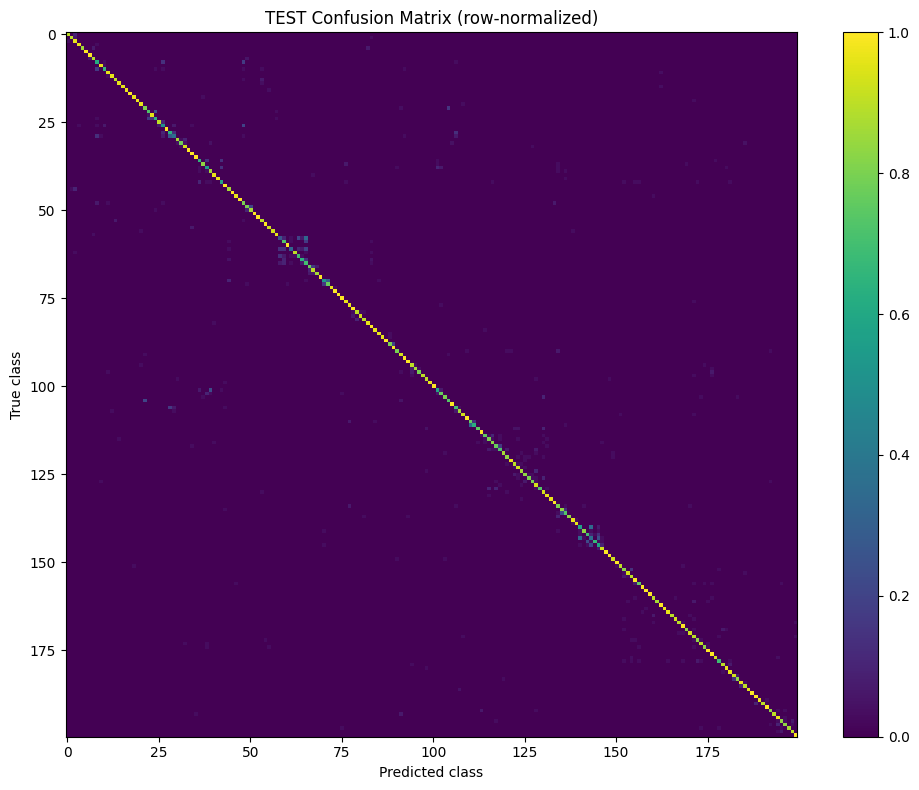

In [ ]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, title="Confusion Matrix (normalized)", normalize=True, max_classes=200):
    cm = cm.copy().astype(np.float64)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm = cm / row_sums

    plt.figure(figsize=(10, 8))
    plt.imshow(cm[:max_classes, :max_classes], aspect="auto")
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(m_test["confusion_matrix"], title="TEST Confusion Matrix (row-normalized)", normalize=True)

In [ ]:
class_name_map = (df[["class_id", "class_name"]]
                  .drop_duplicates()
                  .assign(class_index=lambda x: x["class_id"].astype(int) - 1)
                  .set_index("class_index")["class_name"]
                  .to_dict())

In [ ]:
def per_class_accuracy(y_true, y_pred, num_classes):
    accs = np.zeros(num_classes, dtype=np.float64)
    counts = np.zeros(num_classes, dtype=np.int64)
    for c in range(num_classes):
        mask = (y_true == c)
        counts[c] = mask.sum()
        accs[c] = (y_pred[mask] == c).mean() if counts[c] > 0 else np.nan
    return accs, counts

In [ ]:
# Choose split to analyze
split_name = "TEST"
y_true, y_pred = yt_true, yt_pred

accs, counts = per_class_accuracy(y_true, y_pred, NUM_CLASSES)

rows = []
for c in range(NUM_CLASSES):
    rows.append({
        "class_index": c,
        "class_name": class_name_map.get(c, f"class_{c}"),
        "n_samples": int(counts[c]),
        "accuracy": float(accs[c]) if not np.isnan(accs[c]) else np.nan
    })
pc_df = pd.DataFrame(rows).sort_values("accuracy", ascending=True)
display(pc_df.head(10))

,class_index,class_name,n_samples,accuracy
58,58,059.California_Gull,30,0.266667
61,61,062.Herring_Gull,30,0.333333
29,29,030.Fish_Crow,30,0.366667
143,143,144.Common_Tern,30,0.366667
26,26,027.Shiny_Cowbird,30,0.500000
70,70,071.Long_tailed_Jaeger,30,0.533333
38,38,039.Least_Flycatcher,29,0.551724
42,42,043.Yellow_bellied_Flycatcher,29,0.586207
140,140,141.Artic_Tern,29,0.586207
145,145,146.Forsters_Tern,30,0.600000


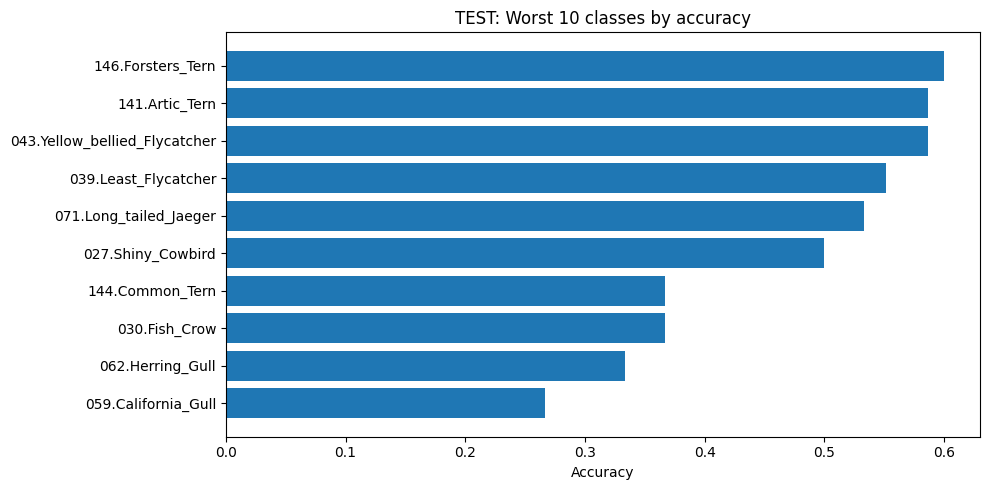

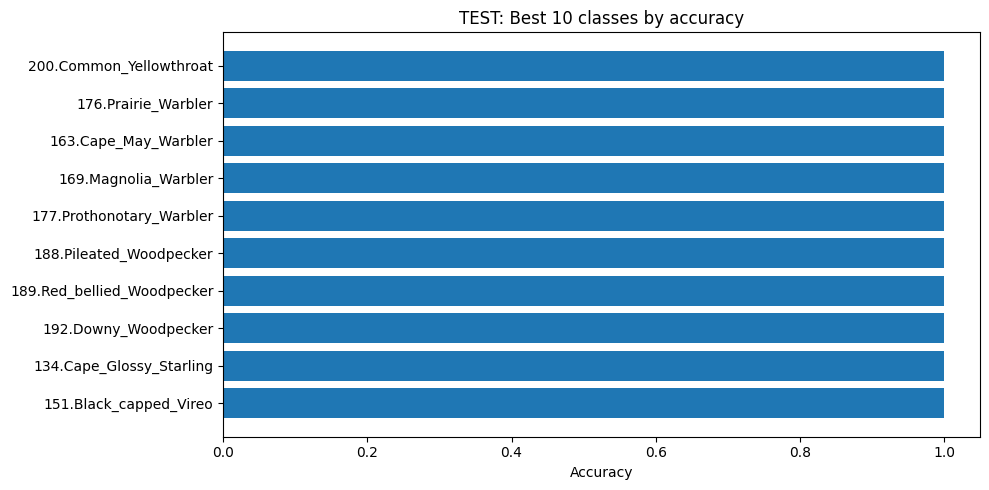

In [ ]:
# Worst/best 10 (ignore NaNs)
pc_df_nonan = pc_df.dropna(subset=["accuracy"]).copy()
worst10 = pc_df_nonan.head(10)
best10  = pc_df_nonan.tail(10)

def plot_bar(df_part, title):
    plt.figure(figsize=(10, 5))
    plt.barh(df_part["class_name"], df_part["accuracy"])
    plt.title(title)
    plt.xlabel("Accuracy")
    plt.tight_layout()
    plt.show()

plot_bar(worst10, f"{split_name}: Worst 10 classes by accuracy")
plot_bar(best10,  f"{split_name}: Best 10 classes by accuracy")

In [ ]:
def get_images_for_class(class_name, n=6, split="test"):
    if split == "test":
        source_df = test_df.copy()
    elif split == "val":
        source_df = val_df.copy()
    else:
        source_df = train_df.copy()

    # map class_id -> class_name
    meta = df[["class_id","class_name"]].drop_duplicates()
    source_df = source_df.merge(meta, on="class_id", how="left")

    subset = source_df[source_df["class_name"] == class_name]

    if len(subset) == 0:
        return []

    rows = subset.sample(min(n, len(subset)), random_state=42)
    return rows["abs_path"].tolist()

In [ ]:
def show_class_images(class_name, n=6, split="test"):
    paths = get_images_for_class(class_name, n=n, split=split)

    if len(paths) == 0:
        print("No images found for", class_name)
        return

    cols = 3
    rows = int(len(paths)/cols) + 1

    plt.figure(figsize=(10, 3*rows))
    for i, p in enumerate(paths):
        plt.subplot(rows, cols, i+1)
        img = Image.open(p).convert("RGB")
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(class_name, fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
# df has class_id (1..200) and class_name
class_name_map = (df[["class_id", "class_name"]]
                  .drop_duplicates()
                  .assign(class_index=lambda x: x["class_id"].astype(int) - 1)
                  .set_index("class_index")["class_name"]
                  .to_dict())

# Check
print("Example:", list(class_name_map.items())[:3])

Example: [(0, '001.Black_footed_Albatross'), (1, '002.Laysan_Albatross'), (2, '003.Sooty_Albatross')]


In [ ]:
def extract_class_names(top_df):
    if "class_name" in top_df.columns:
        return top_df["class_name"].tolist()

    if "class_index" in top_df.columns:
        return [class_name_map[int(ci)] for ci in top_df["class_index"].tolist()]

    if "class_id" in top_df.columns:
        # class_id is 1..200
        return [class_name_map[int(cid) - 1] for cid in top_df["class_id"].tolist()]

    raise KeyError(f"Could not find class_name/class_index/class_id in columns: {top_df.columns.tolist()}")

worst_names = extract_class_names(worst10)
best_names  = extract_class_names(best10)

print("Worst names:", worst_names[:3])
print("Best names :", best_names[:3])

Worst names: ['059.California_Gull', '062.Herring_Gull', '030.Fish_Crow']
Best names : ['151.Black_capped_Vireo', '134.Cape_Glossy_Starling', '192.Downy_Woodpecker']


In [ ]:
# Ensure test_df has a class index we can map from
# Prefer class_id (1..200). If only class_index exists, use that.
if "class_id" in test_df.columns:
    test_tmp = test_df.copy()
    test_tmp["class_index"] = test_tmp["class_id"].astype(int) - 1
elif "class_index" in test_df.columns:
    test_tmp = test_df.copy()
else:
    raise KeyError(f"test_df must have class_id or class_index. Columns: {test_df.columns.tolist()}")

# Map to class_name using the dict from Chunk 1
test_tmp["class_name"] = test_tmp["class_index"].map(class_name_map)

print("Columns now:", test_tmp.columns.tolist())
print("Missing class_name rows:", test_tmp["class_name"].isna().sum())
test_tmp[["class_index","class_name"]].head()

Columns now: ['image_id', 'rel_path', 'abs_path', 'class_id', 'is_train', 'x', 'y', 'w', 'h', 'class_name', 'class_index']
Missing class_name rows: 0


,class_index,class_name
0,0,001.Black_footed_Albatross
2,0,001.Black_footed_Albatross
5,0,001.Black_footed_Albatross
9,0,001.Black_footed_Albatross
11,0,001.Black_footed_Albatross


In [ ]:
from PIL import Image

def show_class_images(class_name, n=6):
    subset = test_tmp[test_tmp["class_name"] == class_name]
    if len(subset) == 0:
        print("No images for:", class_name)
        return

    sample = subset.sample(min(n, len(subset)), random_state=42)["abs_path"].tolist()

    cols = 3
    rows = (len(sample) + cols - 1) // cols
    plt.figure(figsize=(10, 3 * rows))

    for i, p in enumerate(sample):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(p).convert("RGB")
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(class_name, fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
# worst
for cname in worst_names:
    show_class_images(cname, n=6)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# best
for cname in best_names:
    show_class_images(cname, n=6)

Output hidden; open in https://colab.research.google.com to view.